# Global bound in the scattered-voltage basis $V_\mathrm{sca}$: 2:1 copper patch, $ka = 1$

Same as `VscatBound.ipynb` (dipole), with the operators `*_patch21ka1.txt` (233 basis functions).

Global bound on the radiated power with overall power conservation (real and imaginary part), formulated in the scattered voltage
$V_\mathrm{sca} = -Z_0 I$ instead of the current $I$ (alternative to `VtotBound.ipynb`, where $V_\mathrm{tot} = V + V_\mathrm{sca}$).

The pointwise relation $I_i^*\left(Z_s I_i - V_i - V_{\mathrm{sca},i}\right) = 0$ holds for any structure, so the left factor must stay $I$.
The current is eliminated through the field equation, valid everywhere,
$$I = -W V_\mathrm{sca}, \qquad W = Z_0^{-1} .$$
This is an invertible linear (not affine) change of variables, a pure shift of $V_\mathrm{tot}$ by the known $V$, so the bound must
coincide with the bound in the $I$ basis. Since $V_\mathrm{sca} = 0$ corresponds to the empty design region, the constant
term of every power conservation constraint vanishes, and all constraints (global and local) are of the shared projector form
of dolphindes, unlike in the $V_\mathrm{tot}$ basis, where they enter as general constraints.

In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [2]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_patch21ka1.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_patch21ka1.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_patch21ka1.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_patch21ka1.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


## Objective in $V_\mathrm{sca}$

With $I = -W V_\mathrm{sca}$ the radiated power $\tfrac12 I^H R_0 I$ takes the dolphindes form
$-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$, $x = V_\mathrm{sca}$, with
$$A_0 = -\tfrac12 W^H R_0 W,\qquad s_0 = 0,\qquad c_0 = 0 .$$
The quadratic part is identical to the $V_\mathrm{tot}$ formulation.

In [4]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = np.zeros(Ndes, dtype=complex)
obj0 = 0.0

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

Vfull = -Z0 @ Ifull # scattered voltage for full plate
print(f"Objective for full plate in Vsca: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W)")

cond(Z0) = 1.750e+04
Objective for full plate in Vsca: 1.010821e+01 W (I basis 1.010821e+01 W)


## Power conservation in the shared projector form

For a complex diagonal projector $P = \operatorname{diag}(p)$ the constraint $\operatorname{Re}\left[I^H P (V + V_\mathrm{sca} - Z_s I)\right] = 0$
holds for any structure. With $I = -W V_\mathrm{sca}$ it reads $\operatorname{Re}\left(-x^H B x + 2x^H s\right) = 0$,
$$B = W^H P (1 + Z_s W),\qquad s = -\tfrac12 W^H P V ,$$
without a constant. Using $\operatorname{Re}(x^H B x) = \operatorname{Re}(x^H B^H x)$, $B^H = (1 + Z_s^* W^H)\, P^*\, W$, this is the shared projector form
$\operatorname{Re}\left(-x^H A_1 P' A_2 x + 2 x^H A_2^H P'^H s_1\right) = 0$ with
$$A_1 = 1 + Z_s^* W^H,\qquad A_2 = W,\qquad s_1 = -\tfrac12 V,\qquad P' = P^H = \operatorname{diag}(p^*),$$
i.e. the current-basis constraint with $U^H = A_1$ and $I = -A_2 x$ written in $V_\mathrm{sca}$.

The global real ($p = \mathbf 1$) and reactive ($p = -j\mathbf 1$) power constraints are $P' = \mathbf 1$ and $P' = j\mathbf 1$.
For $P' = \mathbf 1$, $\operatorname{Sym}(A_1 A_2) = W^H \operatorname{Re}(Z_\mathrm{tot}) W$ (using $\operatorname{Sym}W = W^H R_0 W$),
the congruent image of the $I$-basis real power constraint.

In [5]:
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc

qList = [1, -1j]   # real and imaginary part (real and reactive power), p = q 1
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]   # P' = diag(p^*)

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def directRes(Vsca, p):
    # Re[I^H diag(p) (V + Vsca - Zs I)] evaluated directly
    I = VtoI(Vsca)
    return(np.real(np.sum(p*np.conj(I)*(Vinc + Vsca - Zs*I))))

print("power conservation residuals at full plate:",
      [f"{projRes(Vfull, Pp):.2e} (direct {directRes(Vfull, q*np.ones(Ndes)):.2e})" for Pp, q in zip(Plist, qList)])

# check: shared projector form equals the direct constraint for a random projector at a random point
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random p, random x: shared form {projRes(xRand, sp.diags(np.conj(pRand))):.6e}, direct {directRes(xRand, pRand):.6e}")

power conservation residuals at full plate: ['-3.38e-13 (direct -3.44e-13)', '2.26e-12 (direct 2.26e-12)']
random p, random x: shared form 2.897688e+00, direct 2.897688e+00


## Dual problem

The unnormalized real power multiplier $\lambda > \tfrac12$ makes $A = -\tfrac12 W^H R_0 W + \lambda W^H \operatorname{Re}(Z_\mathrm{tot}) W$
positive definite, which gives a dual feasible starting point.

In [6]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

lags_init = np.array([1.0, 0.0])   # lambda = 1 on the real power constraint
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.012093e+01 W, time: 0.06s, Lagrange multipliers: [ 0.98806808 -0.03777125]


In [7]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), full plate {Pfull:.6e} W")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist])

minimum eigenvalue of A: 1.813e-06
dual bound 1.012093e+01 W, P(x*) 1.012093e+01 W (I basis 1.012093e+01 W), full plate 1.010821e+01 W
constraint residuals at x*: ['1.67e-08', '2.30e-07']


## Reference: global bound in the $I$ basis

Same constraints with shared projectors in the current basis (as in `densityConstraintsImag.ipynb`). The bounds must agree.

In [8]:
Umat = -1j * Ztot.conj()/np.conj(Zs)   # A1 = U^H with U = j Ztot (Ztot symmetric)
eVec = 1j * Vinc / 2/Zs
Pdiags = np.conj(Zs) * np.column_stack([np.ones(Ndes), 1j*np.ones(Ndes)]).astype(complex)  # global: Im and Re part
PlistI = [sp.diags(Pdiags[:, i]) for i in range(Pdiags.shape[1])]

QCQP_I = DenseSharedProjQCQP(-0.5*R0, np.zeros(Ndes, dtype=complex), 0, Umat, eVec, PlistI, verbose=0)
resultI = QCQP_I.solve_current_dual_problem(method='newton', init_lags=np.array([0.0, 1.0]), opt_params=opt_params)
print(f"I basis bound: {resultI[0]:.6e} W, Vsca basis bound: {result[0]:.6e} W, relative difference {abs(resultI[0]-result[0])/resultI[0]:.2e}")
print(f"relative difference of x*: {np.linalg.norm(QCQP_I.current_xstar - Istar)/np.linalg.norm(QCQP_I.current_xstar):.2e}")

I basis bound: 1.012093e+01 W, Vsca basis bound: 1.012093e+01 W, relative difference 1.54e-12
relative difference of x*: 3.90e-08


## Local projector constraints by GCD

Since the local constraints share $A_1$, $A_2$, $s_1$ with the global ones, they are generated directly by
`dolphindes.cvxopt.gcd.run_gcd`. Each GCD iteration adds two diagonal projectors $P' = \operatorname{diag}(p'^*)$:

1. **Strongest local violation:** $p'_i = (2s_1 - A_1^H x^\star)_i (A_2 x^\star)_i^*$, which equals
   $I_i^{\star *}\left(V + V^\star_{\mathrm{sca}} - Z_s I^\star\right)_i$ with $I^\star = -W x^\star$, the pointwise violation
   of the power conservation (zero for any physical structure).
2. **Minimal eigenvalue:** $p'_i = (A_1^H v)_i (A_2 v)_i^*$ for the eigenvector $v$ of $A(\lambda)$ with the smallest eigenvalue,
   normalized elementwise to unit modulus.

The projectors are kept orthonormal in the Hilbert-Schmidt metric of the constraints, and the number of projectors is capped at
`max_proj_cstrt_num`, which is set large enough that no constraints are merged within `max_gcd_iter_num` iterations.

In [9]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

Ngcd = 20   # number of GCD iterations, each adds a max violation and a min eigenvalue projector

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=opt_params)

def localViolation(Vsca):
    # pointwise w_i = I_i^* (V + Vsca - Zs I)_i, zero for any physical structure
    I = VtoI(Vsca)
    return(np.conj(I)*(Vinc + Vsca - Zs*I))

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"bound: {QCQP.current_dual:.6e} -> {gQCQP.current_dual:.6e} W (full plate {Pfull:.6e} W), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             10.120932760127522.


min eigenvalue: 1.812903e-06


At GCD iteration #2, best dual bound found is             10.113198452266063.
min eigenvalue: 1.421461e-06


At GCD iteration #3, best dual bound found is             10.113175883313692.
min eigenvalue: 1.420209e-06


At GCD iteration #4, best dual bound found is             10.112937261936628.
min eigenvalue: 1.408315e-06


...

At GCD iteration #17, best dual bound found is             10.109552176204414.
min eigenvalue: 1.200867e-06


At GCD iteration #18, best dual bound found is             10.109461312295785.
min eigenvalue: 1.194138e-06


At GCD iteration #19, best dual bound found is             10.109387288344156.
min eigenvalue: 1.188698e-06


At GCD iteration #20, best dual bound found is             10.109326211875413.
min eigenvalue: 1.184154e-06


At GCD iteration #21, best dual bound found is             10.109273733891737.
bound: 1.012093e+01 -> 1.010927e+01 W (full plate 1.010821e+01 W), 42 projectors, 3.96s


minimum eigenvalue of A: 1.180e-06
dual bound 1.010927e+01 W, P(x*) 1.010927e+01 W
max |constraint residual| at x*: 1.82e-08 (global), 7.02e-05 (all)
||local violation||: global 8.605e-01, GCD 1.400e+00


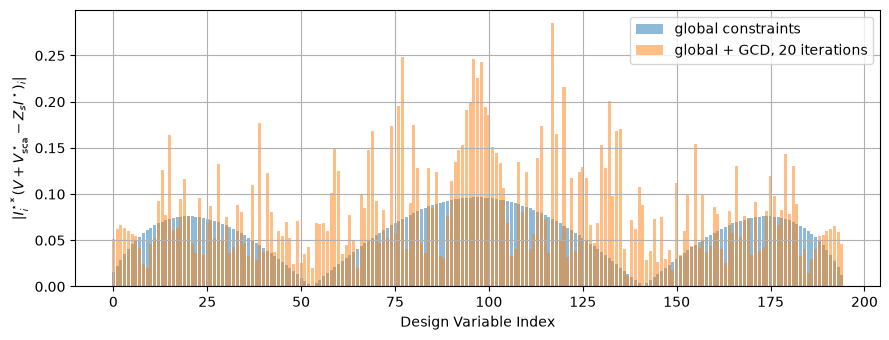

In [10]:
import matplotlib.pyplot as plt

Vstar = gQCQP.current_xstar
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(gQCQP._get_total_A(gQCQP.current_lags)))):.3e}")
print(f"dual bound {gQCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W")
PlistG = gQCQP.Proj.get_Pdata_column_stack()
print(f"max |constraint residual| at x*: {max(abs(projRes(Vstar, Pp)) for Pp in Plist):.2e} (global), "
      f"{max(abs(projRes(Vstar, sp.diags(PlistG[:, j]))) for j in range(PlistG.shape[1])):.2e} (all)")
print(f"||local violation||: global {np.linalg.norm(localViolation(QCQP.current_xstar)):.3e}, "
      f"GCD {np.linalg.norm(localViolation(Vstar)):.3e}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(np.arange(Ndes), np.abs(localViolation(QCQP.current_xstar)), alpha=0.5, label='global constraints')
ax.bar(np.arange(Ndes), np.abs(localViolation(Vstar)), alpha=0.5, label=f'global + GCD, {Ngcd} iterations')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel(r'$|I^{\star *}_i(V + V^\star_\mathrm{sca} - Z_s I^\star)_i|$')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Inferred complex material density

Material density per basis function (as in `densityConstraintsImag.ipynb`), from the total voltage $V + V_\mathrm{sca}$,
$$\rho_i = \frac{Z_s I_i}{V_i + V_{\mathrm{sca},i}}, \qquad I = -W V_\mathrm{sca},$$
equal to 1 on material and 0 on empty basis functions for a physical structure.

global constraints: Re rho in [-0.264, 1.228], Im rho in [-0.178, 0.710], ||Im rho||/||rho|| 5.454e-01
global + GCD, 20 iterations: Re rho in [-0.103, 0.148], Im rho in [-0.099, 0.078], ||Im rho||/||rho|| 6.540e-01


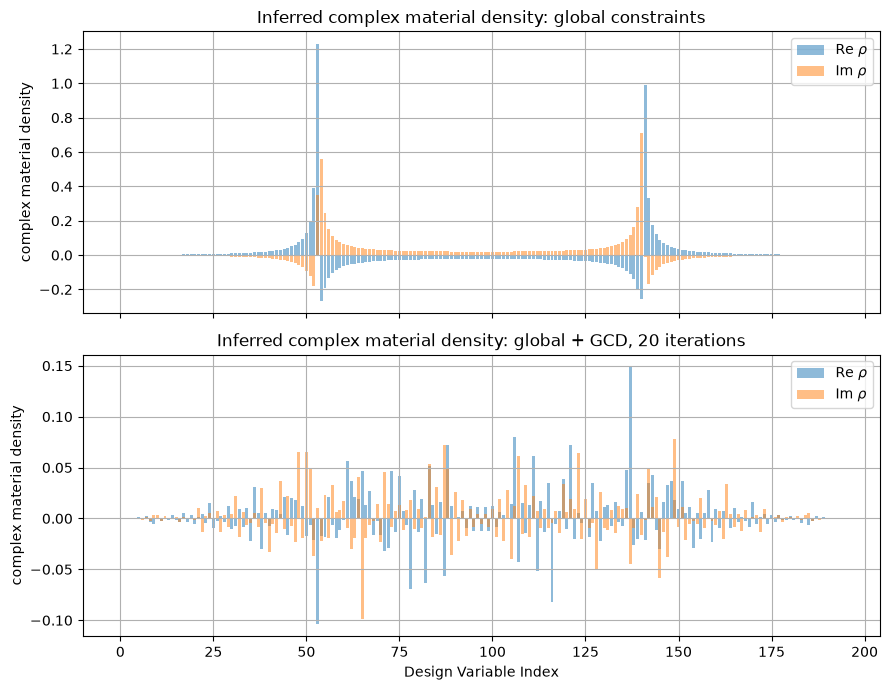

In [11]:
def complexDensity(Vsca):
    # inferred complex material density rho = Zs I / (V + Vsca) (Cholesky space)
    return Zs*VtoI(Vsca)/(Vinc + Vsca)

rhoGlob = complexDensity(QCQP.current_xstar)    # global constraints
rhoLoc = complexDensity(gQCQP.current_xstar)    # after Ngcd GCD iterations
cases = [("global constraints", rhoGlob), (f"global + GCD, {Ngcd} iterations", rhoLoc)]
for name, rho in cases:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], "
          f"Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, cases):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

## Inference optimization over the material density $\rho$

The ratio above gives a complex $\rho$ with no bounds. A physical structure needs a real $\rho_i \in [0, 1]$ such that the current is that
of the material excited by the total field, $I_i = \rho_i\, Z_s^{-1} E_{\mathrm{tot},i}$ with $E_\mathrm{tot} = V + V_\mathrm{sca}$.
The density is therefore inferred from the fit
$$\min_{\rho\in[0,1]^N} \left\| \operatorname{diag}(\rho)\, Z_s^{-1} E_\mathrm{tot} - I \right\|^2, \qquad I = -W V_\mathrm{sca},$$
which separates over the basis functions. With $b_i = E_{\mathrm{tot},i}/Z_s$ the minimizer is the projection onto the box
$$\rho_i = \operatorname{clip}\!\left(\frac{\operatorname{Re}(b_i^* I_i)}{|b_i|^2},\, 0,\, 1\right).$$
The design is then checked by solving the physical problem $(Z_s + \operatorname{diag}(\rho) Z_0)\, I = \operatorname{diag}(\rho)\, V$
and by a threshold sweep for a binary structure.

In [12]:
def fitDensity(Vsca):
    # argmin_{rho in [0,1]^N} || rho Etot/Zs - I ||, separable: projection of the pointwise least squares solution
    b = (Vinc + Vsca)/Zs
    I = VtoI(Vsca)
    rho = np.clip(np.real(np.conj(b)*I)/np.abs(b)**2, 0, 1)
    res = np.linalg.norm(rho*b - I)/np.linalg.norm(I)
    return rho, res

def realizedObj(rho):
    # radiated power of the structure with density rho: (Zs + diag(rho) Z0) I = diag(rho) V
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObjI(I)

rhoFull, resFull = fitDensity(Vfull)
print(f"full plate check: rho in [{rhoFull.min():.6f}, {rhoFull.max():.6f}], relative fit residual {resFull:.2e}")

ths = np.linspace(0.05, 0.95, 19)
fits = {}
print(f"dual bound: global {QCQP.current_dual:.6e} W, GCD {gQCQP.current_dual:.6e} W, full plate {Pfull:.6e} W")
for name, Vs in [("global constraints", QCQP.current_xstar), (f"global + GCD, {Ngcd} iterations", gQCQP.current_xstar)]:
    rho, res = fitDensity(Vs)
    Pbin = np.array([realizedObj((rho > t).astype(float)) for t in ths])
    fits[name] = (rho, Pbin)
    print(f"{name}: relative fit residual {res:.3e}, mean density {rho.mean():.3f}, "
          f"realized objective {realizedObj(rho):.6e} W, best binary {Pbin.max():.6e} W (threshold {ths[np.argmax(Pbin)]:.2f})")

full plate check: rho in [1.000000, 1.000000], relative fit residual 3.91e-10
dual bound: global 1.012093e+01 W, GCD 1.010927e+01 W, full plate 1.010821e+01 W
global constraints: relative fit residual 9.086e-01, mean density 0.024, realized objective 9.511796e-04 W, best binary 4.415367e-08 W (threshold 0.05)
global + GCD, 20 iterations: relative fit residual 8.454e-01, mean density 0.009, realized objective 4.425132e-07 W, best binary 2.398600e-10 W (threshold 0.05)


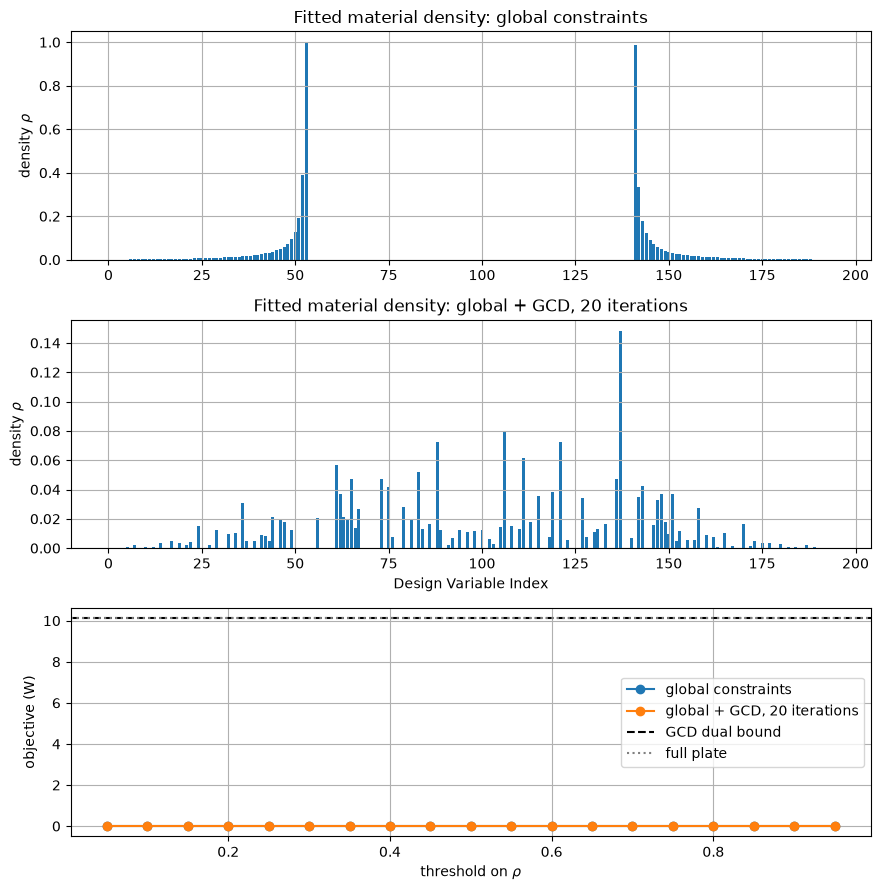

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, (name, (rho, _)) in zip(axes[:2], fits.items()):
    ax.bar(np.arange(Ndes), rho)
    ax.set_ylabel(r'density $\rho$'); ax.set_title(f'Fitted material density: {name}'); ax.grid(True)
axes[1].set_xlabel('Design Variable Index')
for name, (_, Pbin) in fits.items():
    axes[2].plot(ths, Pbin, 'o-', label=name)
axes[2].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_xlabel(r'threshold on $\rho$'); axes[2].set_ylabel('objective (W)'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

## Pointwise voltage fitting of $\rho_\mathrm{inf}$

The fit above needs the current $I = -W V_\mathrm{sca}$, i.e. the ill-conditioned $W = Z_0^{-1}$. For a realizable structure
$Z_s I = \rho_\mathrm{inf} V_\mathrm{tot}$, $\rho_\mathrm{inf} = \operatorname{diag}(\rho)$, $V_\mathrm{tot} = V + V_\mathrm{sca}$; multiplying by $-Z_0$ gives the
relation in voltages only,
$$Z_s V_\mathrm{sca} + Z_0\, \rho_\mathrm{inf} V_\mathrm{tot} = 0 .$$
The density is fitted from the dual solution by
$$\min_{\rho\in[0,1]^N} \left\| Z_s V_\mathrm{sca} + Z_0 D_v \rho \right\|^2, \qquad D_v = \operatorname{diag}(V_\mathrm{tot}),$$
a bounded linear least-squares problem in the real $\rho$ (solved with `scipy.optimize.lsq_linear` on the stacked real and imaginary parts).
The residual equals $-Z_0(Z_s I - \rho_\mathrm{inf} V_\mathrm{tot})$, so this is the current fit above measured in the $Z_0^H Z_0$ norm; it is not separable.
Keeping only the diagonal of the Hessian $H_v = \operatorname{Re}(D_v^H Z_0^H Z_0 D_v)$, with $\gamma_i = \|Z_0 e_i\|^2$, gives the separable estimate
$$\rho_i \approx \operatorname{clip}\!\left(-\frac{\operatorname{Re}\left[Z_s\, V_{\mathrm{tot},i}^* (Z_0^H V_\mathrm{sca})_i\right]}{\gamma_i |V_{\mathrm{tot},i}|^2},\, 0,\, 1\right).$$

In [14]:
from scipy.optimize import lsq_linear

def fitDensityVoltage(Vsca):
    # argmin_{rho in [0,1]^N} || Zs Vsca + Z0 diag(Vtot) rho ||, Vtot = V + Vsca (no Z0^{-1})
    Vtot = Vinc + Vsca
    M = Z0 * Vtot[None, :]   # Z0 @ diag(Vtot)
    r = -Zs * Vsca
    sol = lsq_linear(np.vstack([M.real, M.imag]), np.concatenate([r.real, r.imag]), bounds=(0, 1),
                     method='bvls', tol=1e-12)
    rho = sol.x
    res = np.linalg.norm(Zs*Vsca + M @ rho)/np.linalg.norm(Zs*Vsca)
    return rho, res

def fitDensityVoltageDiag(Vsca):
    # separable estimate: diagonal of the Hessian Re(D_v^H Z0^H Z0 D_v)
    Vtot = Vinc + Vsca
    gamma = np.sum(np.abs(Z0)**2, axis=0)   # ||Z0 e_i||^2
    rho = np.clip(-np.real(Zs*np.conj(Vtot)*(Z0.conj().T @ Vsca))/(gamma*np.abs(Vtot)**2), 0, 1)
    res = np.linalg.norm(Zs*Vsca + Z0 @ (rho*Vtot))/np.linalg.norm(Zs*Vsca)
    return rho, res

rhoFullV, resFullV = fitDensityVoltage(Vfull)
print(f"full plate check: rho in [{rhoFullV.min():.6f}, {rhoFullV.max():.6f}], relative voltage residual {resFullV:.2e}")

fitsV = {}
print(f"dual bound: global {QCQP.current_dual:.6e} W, GCD {gQCQP.current_dual:.6e} W, full plate {Pfull:.6e} W")
for name, Vs in [("global constraints", QCQP.current_xstar), (f"global + GCD, {Ngcd} iterations", gQCQP.current_xstar)]:
    for label, fit in [("voltage fit", fitDensityVoltage), ("voltage fit (diag)", fitDensityVoltageDiag)]:
        t1 = time.time()
        rho, res = fit(Vs)
        Pbin = np.array([realizedObj((rho > t).astype(float)) for t in ths])
        fitsV[(name, label)] = (rho, Pbin)
        print(f"{name}, {label}: relative voltage residual {res:.3e}, mean density {rho.mean():.2e}, max {rho.max():.2e}, nonzero {np.count_nonzero(rho > 1e-6)}, "
              f"realized objective {realizedObj(rho):.6e} W, best binary {Pbin.max():.6e} W "
              f"(threshold {ths[np.argmax(Pbin)]:.2f}), {time.time()-t1:.2f}s")

full plate check: rho in [1.000000, 1.000000], relative voltage residual 3.54e-06
dual bound: global 1.012093e+01 W, GCD 1.010927e+01 W, full plate 1.010821e+01 W
global constraints, voltage fit: relative voltage residual 7.233e-01, mean density 3.89e-04, max 5.57e-04, nonzero 195, realized objective 9.213016e-03 W, best binary 0.000000e+00 W (threshold 0.05), 0.01s
global constraints, voltage fit (diag): relative voltage residual 9.958e-01, mean density 1.36e-08, max 7.54e-07, nonzero 0, realized objective 1.599009e-11 W, best binary 0.000000e+00 W (threshold 0.05), 0.01s
global + GCD, 20 iterations, voltage fit: relative voltage residual 8.160e-01, mean density 1.08e-06, max 7.04e-06, nonzero 95, realized objective 7.053917e-08 W, best binary 0.000000e+00 W (threshold 0.05), 0.03s
global + GCD, 20 iterations, voltage fit (diag): relative voltage residual 9.457e-01, mean density 1.19e-06, max 5.26e-06, nonzero 117, realized objective 7.007515e-08 W, best binary 0.000000e+00 W (thresho

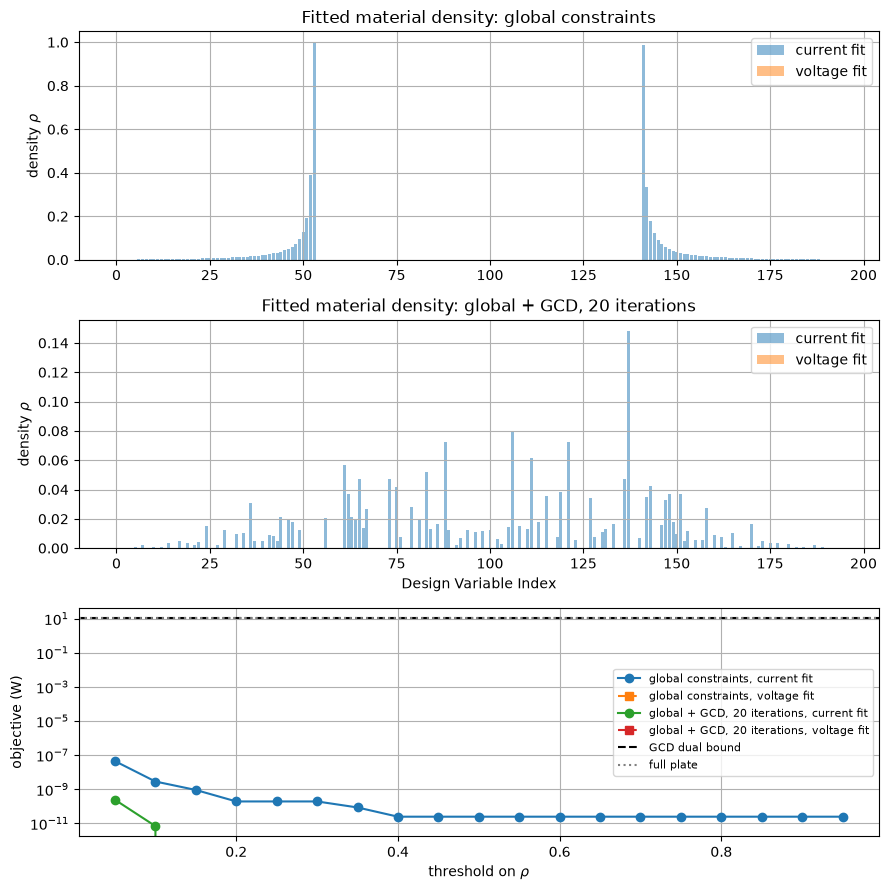

In [15]:
names = list(fits.keys())
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, name in zip(axes[:2], names):
    ax.bar(np.arange(Ndes), fits[name][0], alpha=0.5, label='current fit')
    ax.bar(np.arange(Ndes), fitsV[(name, 'voltage fit')][0], alpha=0.5, label='voltage fit')
    ax.set_ylabel(r'density $\rho$'); ax.set_title(f'Fitted material density: {name}'); ax.legend(); ax.grid(True)
axes[1].set_xlabel('Design Variable Index')
for name in names:
    axes[2].plot(ths, fits[name][1], 'o-', label=f'{name}, current fit')
    axes[2].plot(ths, fitsV[(name, 'voltage fit')][1], 's--', label=f'{name}, voltage fit')
axes[2].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_yscale('log')
axes[2].set_xlabel(r'threshold on $\rho$'); axes[2].set_ylabel('objective (W)'); axes[2].legend(fontsize=8); axes[2].grid(True)
plt.tight_layout(); plt.show()

## Fitting in the solution

The density $\rho = \operatorname{diag}(\rho_i)$, $\rho_i \in [0,1]$, whose realized current is closest to the dual current $I = -W V_\mathrm{sca}$,
$$\min_{\rho\in[0,1]^N}\left\| I - (Z_s + \rho Z_0)^{-1} \rho V \right\|^2,$$
where $(Z_s + \rho Z_0) I = \rho V$ is the physical relation of a design with density $\rho$ (i.e. $Z_s I = \rho V_\mathrm{tot}$).
The fit is nonlinear in $\rho$ and solved by `scipy.optimize.least_squares` (bounded trust region), started from the separable current fit
`fitDensity`, with the Jacobian
$$\frac{\partial I(\rho)}{\partial\rho_j} = M^{-1} e_j\, \left(V - Z_0 I(\rho)\right)_j, \qquad M = Z_s + \rho Z_0,\quad I(\rho) = M^{-1}\rho V .$$

In [16]:
from scipy.optimize import least_squares

def fitDensitySolution(Vsca, rho0=None):
    # argmin_{rho in [0,1]^N} || I - (Zs + diag(rho) Z0)^{-1} diag(rho) V ||
    I = VtoI(Vsca)
    def model(rho):
        M = Zs*np.eye(Ndes) + rho[:, None]*Z0
        return M, np.linalg.solve(M, rho*Vinc)
    def fun(rho):
        r = model(rho)[1] - I
        return np.concatenate([r.real, r.imag])
    def jac(rho):
        M, Irho = model(rho)
        J = np.linalg.inv(M) * (Vinc - Z0 @ Irho)[None, :]   # column j: M^{-1} e_j (V - Z0 I)_j
        return np.vstack([J.real, J.imag])
    x0 = np.full(Ndes, 0.5) if rho0 is None else np.clip(rho0, 1e-3, 1 - 1e-3)
    sol = least_squares(fun, x0, jac=jac, bounds=(0, 1), method='trf', xtol=1e-12, ftol=1e-12, max_nfev=500)
    res = np.linalg.norm(model(sol.x)[1] - I)/np.linalg.norm(I)
    return sol.x, res

rho, res = fitDensitySolution(Vfull)
print(f"full plate check: rho in [{rho.min():.6f}, {rho.max():.6f}], relative residual {res:.2e}")

fitsS = {}
for name, Vs in [("global constraints", QCQP.current_xstar), (f"global + GCD, {Ngcd} iterations", gQCQP.current_xstar)]:
    t1 = time.time()
    rho, res = fitDensitySolution(Vs, rho0=fitDensity(Vs)[0])
    Pbin = np.array([realizedObj((rho > t).astype(float)) for t in ths])
    fitsS[name] = (rho, Pbin)
    print(f"{name}: relative residual {res:.3e}, mean density {rho.mean():.3e}, max {rho.max():.3e}, "
          f"realized objective {realizedObj(rho):.6e} W, best binary {Pbin.max():.6e} W "
          f"(threshold {ths[np.argmax(Pbin)]:.2f}), {time.time()-t1:.2f}s")

full plate check: rho in [0.984760, 0.984769], relative residual 2.32e-04
global constraints: relative residual 2.202e-02, mean density 9.998e-01, max 1.000e+00, realized objective 1.010818e+01 W, best binary 1.010821e+01 W (threshold 0.05), 0.07s
global + GCD, 20 iterations: relative residual 2.432e-03, mean density 9.973e-01, max 9.978e-01, realized objective 1.010771e+01 W, best binary 1.010821e+01 W (threshold 0.05), 0.08s


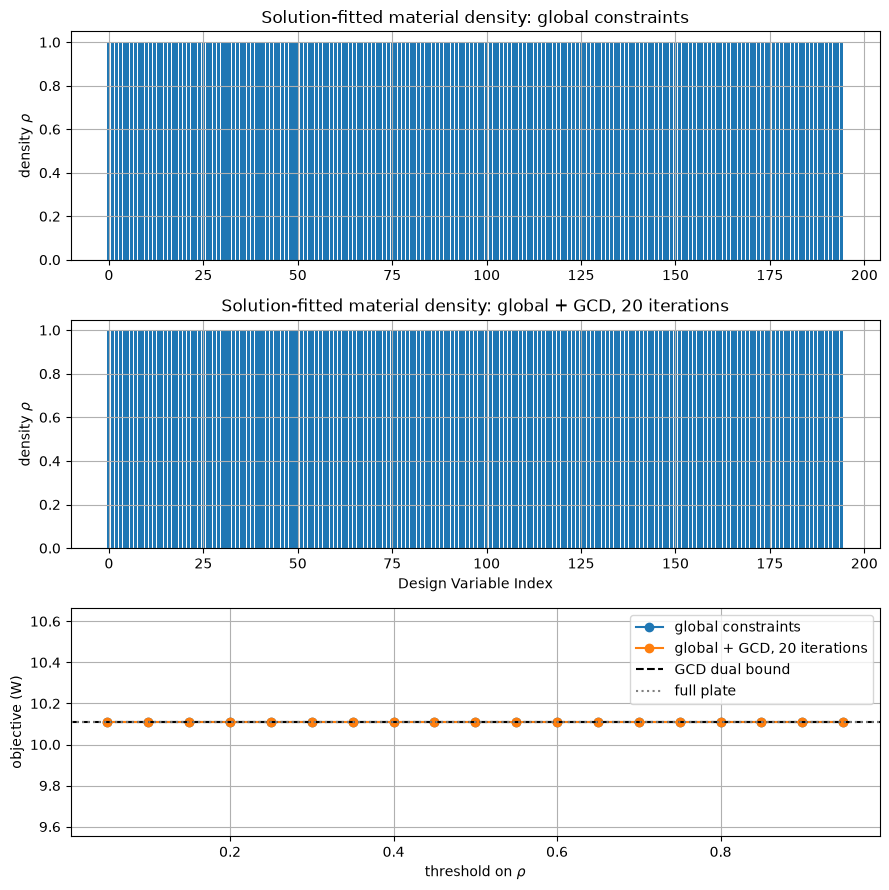

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, name in zip(axes[:2], names):
    ax.bar(np.arange(Ndes), fitsS[name][0])
    ax.set_ylabel(r'density $\rho$'); ax.set_title(f'Solution-fitted material density: {name}'); ax.grid(True)
axes[1].set_xlabel('Design Variable Index')
for name in names:
    axes[2].plot(ths, fitsS[name][1], 'o-', label=name)
axes[2].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_xlabel(r'threshold on $\rho$'); axes[2].set_ylabel('objective (W)'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()